# Chest X-Ray Lung Disease Classification & Clinical Safety Pipeline

## Project Overview
This project develops a robust, end-to-end deep learning pipeline to automatically classify chest X-ray images into six distinct diagnostic categories: **Covid-19, Emphysema, Normal, Pneumonia-Bacterial, Pneumonia-Viral, and Tuberculosis**.

Beyond basic classification, this notebook is specifically structured with **clinical safety and explainability** as primary goals. The comprehensive pipeline features:

* **State-of-the-Art Transfer Learning:** Two-phase training and fine-tuning of advanced convolutional architectures like DenseNet121 and ResNet50.
* **Ensemble Methods:** A soft-voting ensemble across multiple models to improve generalization and predictive robustness.
* **Explainable AI (XAI):** Integration of **Grad-CAM heatmaps** to visually verify that predictions are based on genuine medical pathology rather than irrelevant background artifacts.
* **Production-Ready Clinical Safety Layer:** An Out-of-Distribution (OOD) detector using Isolation Forests to automatically reject invalid non-X-ray inputs, paired with confidence thresholding to flag ambiguous cases for manual physician review.

# Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = '/content/drive/My Drive/AI Projects/Lung Disease/Chest Xray'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

class_names = [
    'Covid-19',
    'Emphysema',
    'Normal',
    'Pneumonia-Bacterial',
    'Pneumonia-Viral',
    'Tuberculosis'
]

for path_name, dir_path in zip(['Train', 'Test', 'Validation'], [train_dir, test_dir, val_dir]):
    if os.path.exists(dir_path):
        print(f"✅ {path_name} directory found.")
    else:
        print(f"❌ {path_name} directory NOT found. Please check the path.")

✅ Train directory found.
✅ Test directory found.
✅ Validation directory found.


# Image Visualization

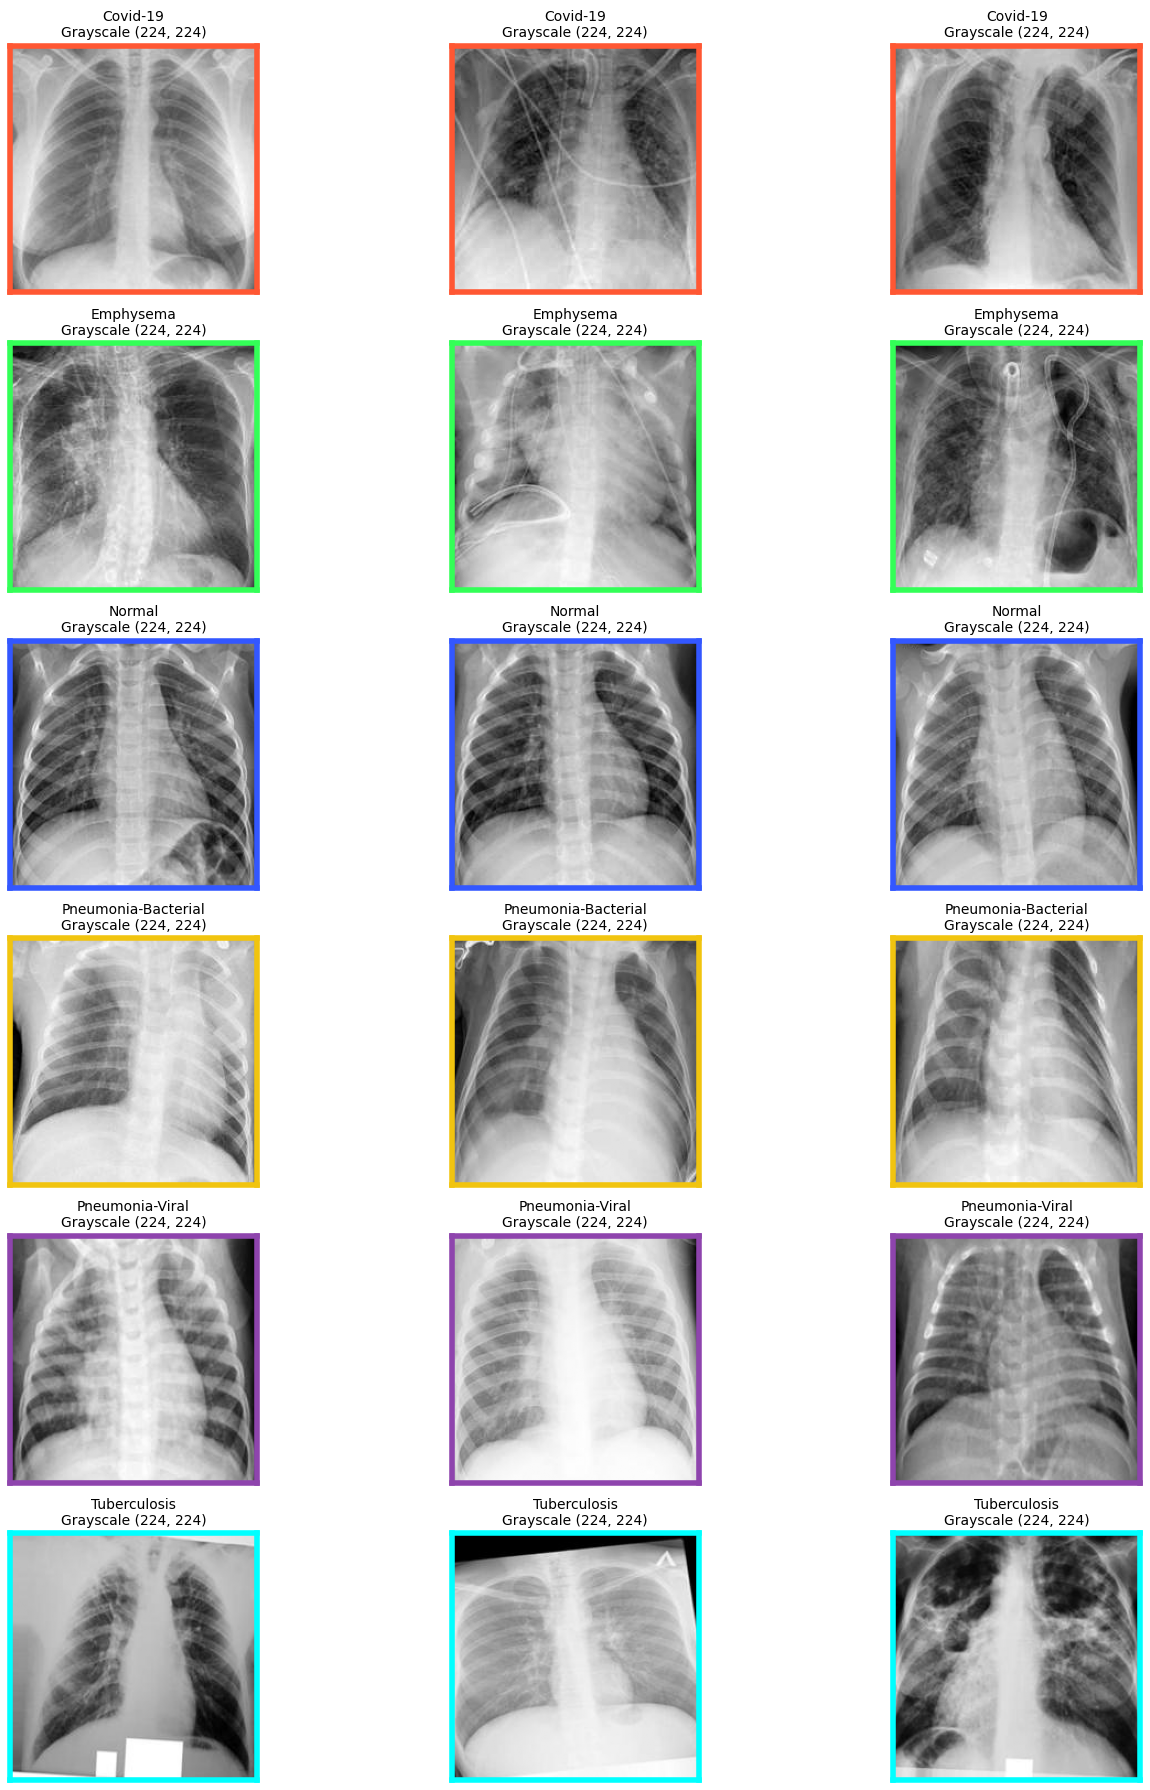

In [ ]:
# We have 6 classes, so we'll create a 6x3 grid instead of 5x3 to show them all
num_classes = len(class_names)
num_samples = 3

fig, axes = plt.subplots(num_classes, num_samples, figsize=(15, 3 * num_classes))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# Define a distinct color for each class
border_colors = ['#FF5733', '#33FF57', '#3357FF', '#F1C40F', '#8E44AD', '#00FFFF']

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)

    if not os.path.exists(class_dir):
        print(f"Directory for {class_name} not found.")
        continue

    # Get list of images
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Select random samples
    selected_images = random.sample(images, min(num_samples, len(images)))

    # Get the color for this class's border
    color = border_colors[i % len(border_colors)]

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)

        # Read image with original channels to check for color vs grayscale
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            continue

        # Determine if grayscale or color based on shape
        shape = img.shape
        if len(shape) == 2:
            color_type = "Grayscale"
            cmap = 'gray'
            img_disp = img
        elif len(shape) == 3 and shape[2] == 3:
            color_type = "Color"
            cmap = None
            img_disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif len(shape) == 3 and shape[2] == 4:
            color_type = "RGBA (Color)"
            cmap = None
            img_disp = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
        else:
            color_type = "Unknown"
            cmap = 'gray'
            img_disp = img

        ax = axes[i, j]
        if cmap:
            ax.imshow(img_disp, cmap=cmap)
        else:
            ax.imshow(img_disp)

        ax.set_title(f"{class_name}\n{color_type} {shape}", fontsize=10)

        # Remove ticks but keep the border (spines)
        ax.set_xticks([])
        ax.set_yticks([])

        # Apply colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)

plt.tight_layout()
plt.show()

# Image Statistics and EDA

### Item Count

In [ ]:
counts_data = []

for split_name, split_dir in zip(['Train', 'Test', 'Validation'], [train_dir, test_dir, val_dir]):
    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        if os.path.exists(class_dir):
            # Count only files (ignore any subdirectories if they accidentally exist)
            num_items = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
        else:
            num_items = 0
        counts_data.append({'Split': split_name, 'Class': class_name, 'Count': num_items})

# Create a DataFrame for better visualization
df_counts = pd.DataFrame(counts_data)

# Pivot the table so Splits are columns and Classes are rows
df_pivot = df_counts.pivot(index='Class', columns='Split', values='Count').fillna(0).astype(int)

# Reorder columns just in case
if set(['Train', 'Validation', 'Test']).issubset(df_pivot.columns):
    df_pivot = df_pivot[['Train', 'Validation', 'Test']]

# Add Total row and column
df_pivot['Total'] = df_pivot.sum(axis=1)
df_pivot.loc['Total'] = df_pivot.sum(axis=0)

print("Number of items in each folder:")
display(df_pivot)

Number of items in each folder:


Split,Train,Validation,Test,Total
Class,,,,
Covid-19,2417,300,300,3017
Emphysema,2050,250,250,2550
Normal,2671,300,300,3271
Pneumonia-Bacterial,2400,300,300,3000
Pneumonia-Viral,2413,300,300,3013
Tuberculosis,2600,298,287,3185
Total,14551,1748,1737,18036


### Target Distribution

/tmp/ipykernel_6506/2708778519.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=train_counts, x='Class', y='Count', palette='viridis')


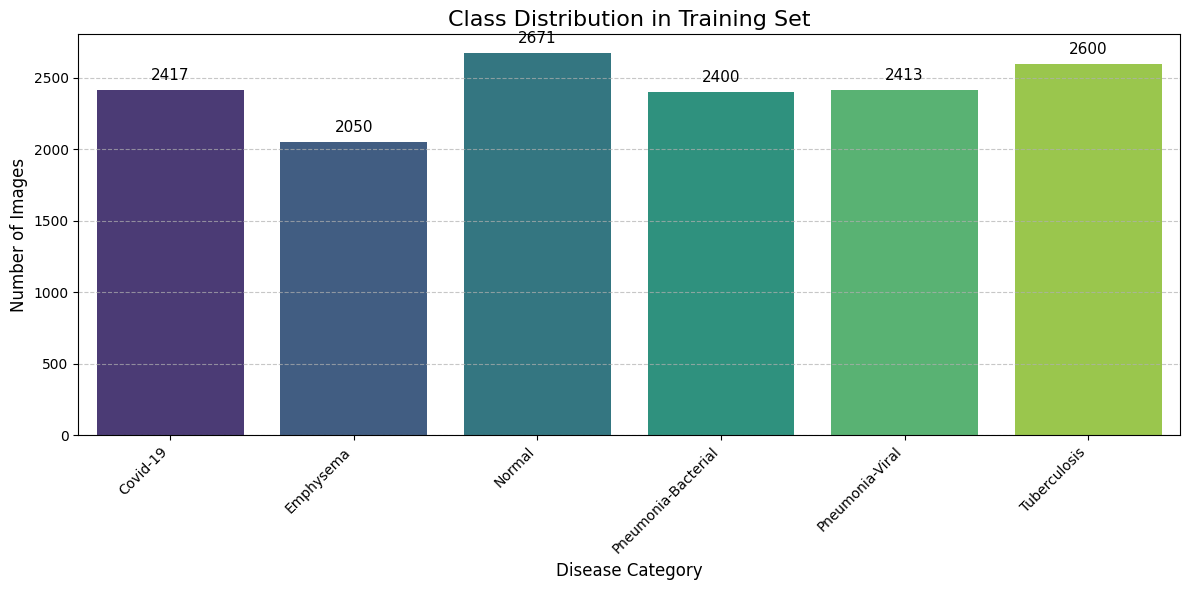

In [ ]:
train_counts = df_counts[df_counts['Split'] == 'Train']

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=train_counts, x='Class', y='Count', palette='viridis')

plt.title('Class Distribution in Training Set', fontsize=16)
plt.xlabel('Disease Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Prepare Before EDA

In [ ]:
from PIL import Image
import random
from tqdm.notebook import tqdm

sample_size = 200     # No need to Load all image to crash system

image_shapes = {}
mean_images = {}
pixel_intensities = {}

print("Processing images for EDA...")
for class_name in tqdm(class_names, desc="Classes"):
    class_dir = os.path.join(train_dir, class_name)
    if not os.path.exists(class_dir):
        continue

    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sampled_images = random.sample(images, min(sample_size, len(images)))

    shapes = []
    pixels = []

    # Initialize an array for the mean image (resizing to 224x224 to allow accumulation)
    mean_img = np.zeros((224, 224), dtype=np.float32)
    valid_img_count = 0

    for img_name in sampled_images:
        img_path = os.path.join(class_dir, img_name)

        # Read for shape using PIL (fast)
        try:
            with Image.open(img_path) as img:
                shapes.append(img.size) # (width, height)
        except Exception:
            continue

        # Read for mean image and histogram
        img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_cv is not None:
            # Subsample pixels (take every 10th pixel) to save memory for histograms
            pixels.extend(img_cv.flatten()[::10])

            # Resize to a common shape to compute the mean image correctly
            img_resized = cv2.resize(img_cv, (224, 224))
            mean_img += img_resized
            valid_img_count += 1

    image_shapes[class_name] = shapes
    if valid_img_count > 0:
        mean_images[class_name] = mean_img / valid_img_count
    pixel_intensities[class_name] = pixels

print("\nEDA Data Collection Complete!")

Processing images for EDA...


Classes:   0%|          | 0/6 [00:00<?, ?it/s]


EDA Data Collection Complete!


# Resize

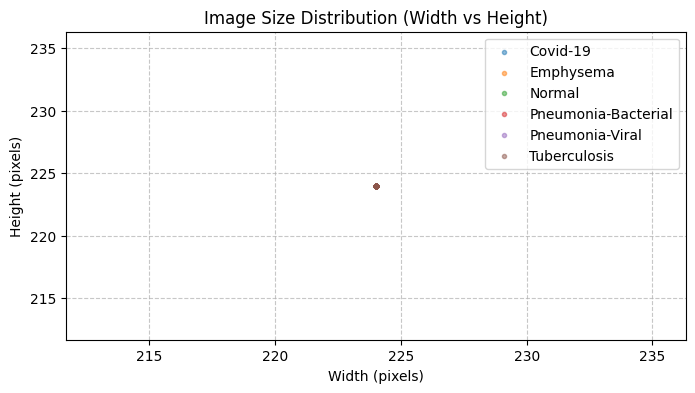


--- Sizing Analysis ---
Found 1 unique image size(s) in the sample.
➡️ CONCLUSION: All sampled images are the same size (224, 224). Resizing not necessary, but standardizing still best practice.


In [ ]:
plt.figure(figsize=(8, 4))
all_shapes = []

for class_name, shapes in image_shapes.items():
    all_shapes.extend(shapes)
    widths = [s[0] for s in shapes]
    heights = [s[1] for s in shapes]
    plt.scatter(widths, heights, label=class_name, alpha=0.5, marker='.')

plt.title('Image Size Distribution (Width vs Height)')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Conclusion on Resizing
unique_shapes = set(all_shapes)
print(f"\n--- Sizing Analysis ---")
print(f"Found {len(unique_shapes)} unique image size(s) in the sample.")
if len(unique_shapes) > 1:
    print("➡️ CONCLUSION: Resizing IS REQUIRED for model training, as images vary in size.")
else:
    print(f"➡️ CONCLUSION: All sampled images are the same size {list(unique_shapes)[0]}. Resizing not necessary, but standardizing still best practice.")

### Mean Image & Pixel Intensity Histogram

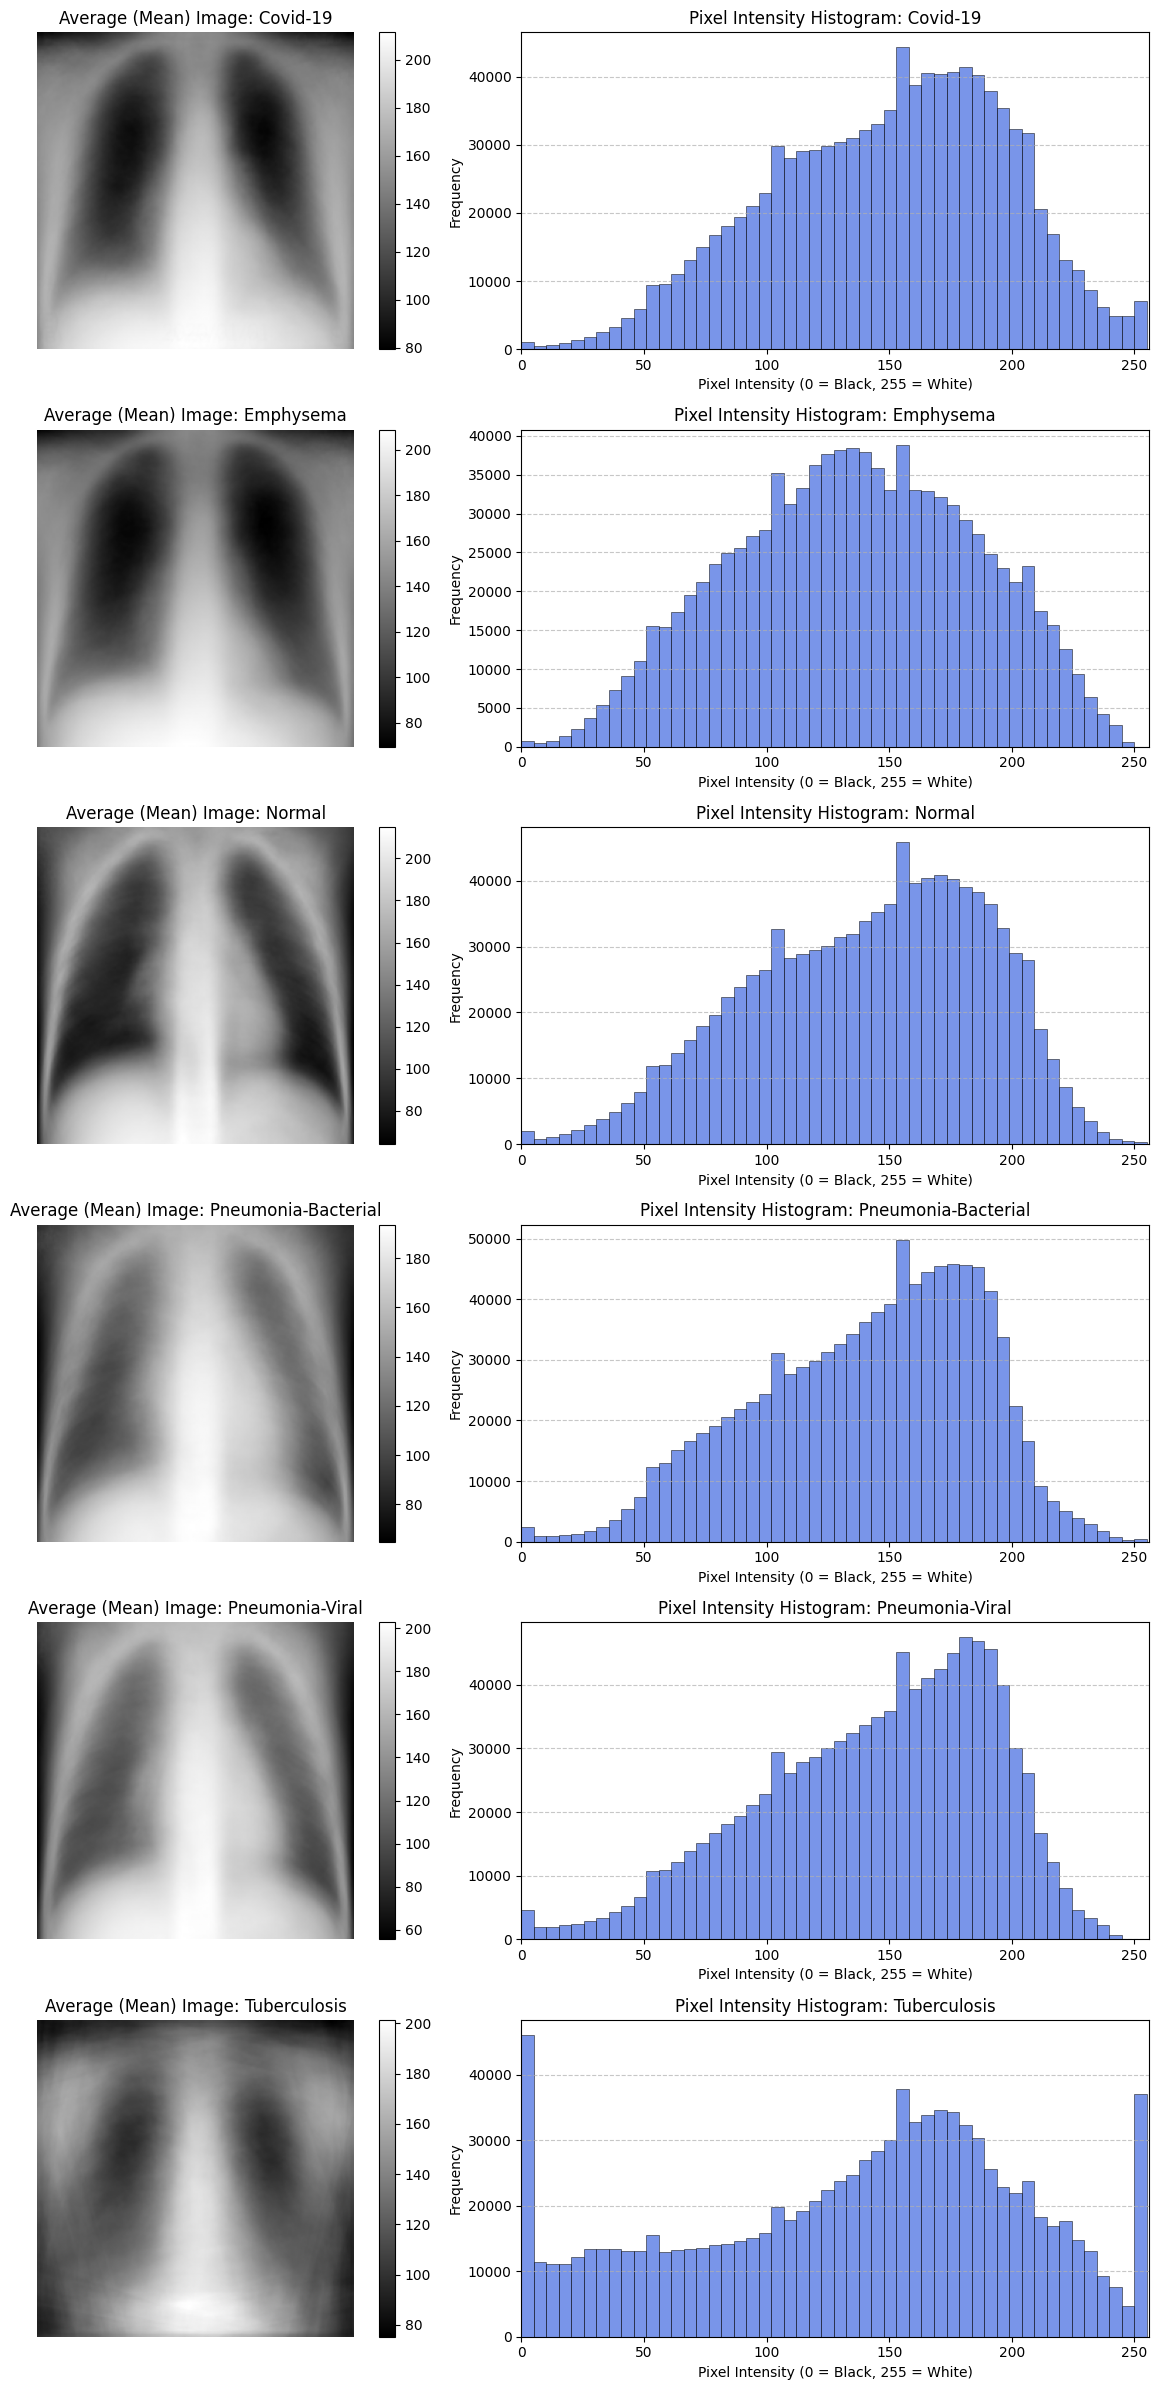

In [ ]:
num_classes = len(class_names)
fig, axes = plt.subplots(num_classes, 2, figsize=(14, 4 * num_classes))
fig.subplots_adjust(hspace=0.4, wspace=0.2)

for i, class_name in enumerate(class_names):
    # A. Mean Image
    ax_img = axes[i, 0]
    if class_name in mean_images:
        im = ax_img.imshow(mean_images[class_name], cmap='gray')
        ax_img.set_title(f'Average (Mean) Image: {class_name}', fontsize=12)
        ax_img.axis('off')
        fig.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    # B. Pixel Intensity Histogram
    ax_hist = axes[i, 1]
    if class_name in pixel_intensities:
        ax_hist.hist(pixel_intensities[class_name], bins=50, color='royalblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax_hist.set_title(f'Pixel Intensity Histogram: {class_name}', fontsize=12)
        ax_hist.set_xlabel('Pixel Intensity (0 = Black, 255 = White)')
        ax_hist.set_ylabel('Frequency')
        ax_hist.set_xlim([0, 256])
        ax_hist.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

*  **Mean Images (Visual Patterns):** The average images reveal distinct structural differences between the disease classes. For instance, 'Normal' X-rays generally show clearer lung fields (darker areas), whereas conditions like 'Pneumonia' or 'Covid-19' exhibit more 'cloudiness' or opacity (lighter gray areas) due to fluid or infection.
* **Pixel Intensities:** The histograms show how the grayscale values (0 to 255) are distributed. While they vary slightly between classes, they cover a broad range. This confirms that normalizing the pixel values (scaling them down to a 0-1 range) will be beneficial for neural network stability.

# Data Preprocessing

### Data Augmentation Setup

For including rotation, flipping, zooming, shearing, and brightness adjustments

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training Data Generator (with augmentation & rescaling)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

# Validation/Test Data Generator (ONLY rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create Data Generators
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nLoading Validation Data...")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle validation data
)

print("\nLoading Test Data...")
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data
)

Loading Training Data...
Found 14551 images belonging to 6 classes.

Loading Validation Data...
Found 1748 images belonging to 6 classes.

Loading Test Data...
Found 1737 images belonging to 6 classes.


### Class Indices Mapping

In [ ]:
# Print the mapping of class names to their numerical indices
print("Class Indices Mapping:")
print(train_generator.class_indices)

Class Indices Mapping:
{'Covid-19': 0, 'Emphysema': 1, 'Normal': 2, 'Pneumonia-Bacterial': 3, 'Pneumonia-Viral': 4, 'Tuberculosis': 5}


### Augmented Sample Preview
Verify that augmentation parameters (rotation, zoom, shear, etc.) produce realistic images and do not distort the X-rays beyond recognition.

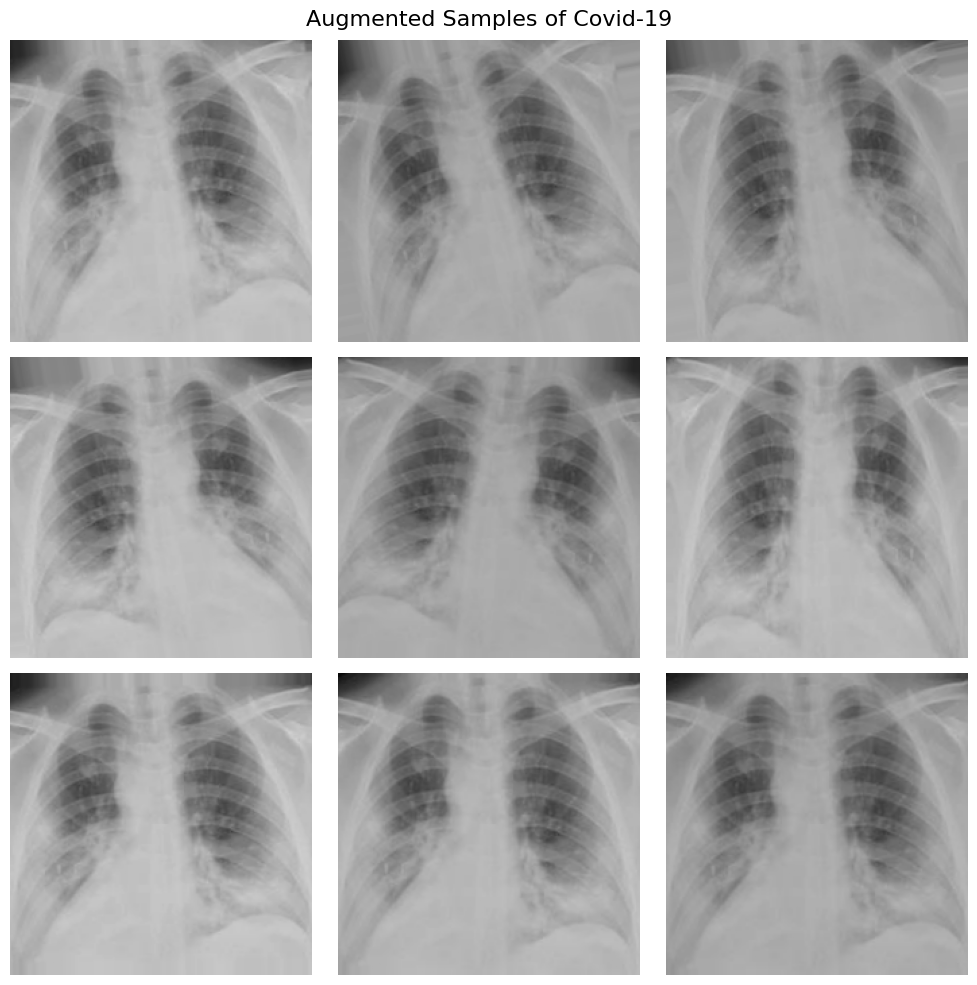

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Select a random class and image
sample_class = class_names[0]
sample_dir = os.path.join(train_dir, sample_class)
sample_image_name = os.listdir(sample_dir)[0]
sample_image_path = os.path.join(sample_dir, sample_image_name)

# Load the image and add a batch dimension
img = load_img(sample_image_path, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Create a generator that yields batches of 1 augmented image
aug_iter = train_datagen.flow(img_array, batch_size=1)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(f'Augmented Samples of {sample_class}', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Generate a new augmented image
    aug_img = next(aug_iter)[0]
    # The train_datagen already applies rescale=1./255, so pixels are in [0, 1]
    ax.imshow(aug_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

Transformations (rotation, shear, zoom, flip, and brightness adjustment) create varied versions of the original image. The structural integrity of the lungs is maintained but the variations introduce enough noise to prevent the model from memorizing exact pixel locations and help it generalize better to unseen data

### Class Imbalance Handling (Class Weights)
Even though our dataset might be relatively balanced, it's best practice to compute exact class weights. This ensures the model pays more attention to underrepresented classes during training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Get the array of true classes from the training generator
train_classes = train_generator.classes

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Convert to a dictionary format required by Keras model.fit()
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights mapped to indices:")
for class_idx, weight in class_weight_dict.items():
    # Reverse lookup the class name from the generator's indices
    class_name = list(train_generator.class_indices.keys())[list(train_generator.class_indices.values()).index(class_idx)]
    print(f"{class_name:20s} (Index {class_idx}): {weight:.4f}")

Class Weights mapped to indices:
Covid-19             (Index 0): 1.0034
Emphysema            (Index 1): 1.1830
Normal               (Index 2): 0.9080
Pneumonia-Bacterial  (Index 3): 1.0105
Pneumonia-Viral      (Index 4): 1.0050
Tuberculosis         (Index 5): 0.9328


* **Overall Balance:** Most weights are very close to **1.0**, which means our dataset is already quite well-balanced across the different diseases.
* **Underrepresented Classes:** **Emphysema (1.1830)** has the highest weight. This indicates it has slightly fewer image samples compared to the rest. The model will penalize mistakes on this class more heavily to ensure it learns its features properly.
* **Overrepresented Classes:** **Normal (0.9080)** and **Tuberculosis (0.9328)** have weights below 1.0. Because they have slightly more samples, their impact on the loss function is scaled down slightly to prevent the model from blindly guessing these majority classes.

# Model Building

We couldve used `ResNet50 -> ResNeXt and ConvNeXt`,

`EfficientNetB0 -> EfficientNetB7, EfficientNetV2`,

`DenseNet121 -> DenseNet169, DenseNet201` but these risks:

*   Overfitting on small dataset
*   Tiny improvement in accuracy
*   Computational High Cost



### Custom CNN Baseline

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Note: num_classes is 6 based on our dataset
custom_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

print("Custom CNN Baseline Summary:")
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Custom CNN Baseline Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

### ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 without the top classification layer
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False  # Freeze the base layers

resnet_model = Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

print("ResNet50 Summary:")
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
ResNet50 Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0 without the top classification layer
effnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
effnet_base.trainable = False  # Freeze initially

effnet_model = Sequential([
    effnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# Helper function for fine-tuning later
def fine_tune_efficientnet(model_base, num_unfreeze=20):
    model_base.trainable = True
    # Freeze all layers except the last 'num_unfreeze' layers
    for layer in model_base.layers[:-num_unfreeze]:
        layer.trainable = False
    print(f"Unfroze the last {num_unfreeze} layers of EfficientNetB0.")

print("EfficientNetB0 Summary:")
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### DenseNet121

In [ ]:
from tensorflow.keras.applications import DenseNet121

# Load DenseNet121 without the top classification layer
densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
densenet_base.trainable = False  # Phase 1: Frozen head first

densenet_model = Sequential([
    densenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# Helper function for fine-tuning later
def fine_tune_densenet(model_base):
    # Phase 2: Unfreeze for fine-tuning
    model_base.trainable = True
    print("Unfroze DenseNet121 base layers for fine-tuning.")

print("DenseNet121 Summary:")
densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
DenseNet121 Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,446 (27.85 MB)

 Trainable params: 263,942 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

# Model Trining

### Callbacks Setup

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# We create a function so each model can have its own uniquely named checkpoint file
def get_callbacks(model_name):
    # Save directly to the mounted Google Drive
    checkpoint_path = f'/content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/{model_name}_best.keras'

    return [
        EarlyStopping(
            monitor='val_loss',
            patience=8,     # Early Stop if not improve after 8 epochs
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

* For Earlystopping to stop overfitting
* ReduceLROnPlateau shrink learning rate when not learning
* ModelCheckpoint If accuracy drop in later epoch take prev one

### Train All Models (Phase 1: Initial Training)

In [ ]:
from tensorflow.keras.optimizers import Adam

models_dict = {
    'Custom_CNN': custom_cnn,
    'ResNet50': resnet_model,
    'EfficientNetB0': effnet_model,
    'DenseNet121': densenet_model
}

INITIAL_EPOCHS = 15

for name, model in models_dict.items():
    print(f"\n{'='*50}\nTraining {name} - Phase 1\n{'='*50}")

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=INITIAL_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(name)
    )


Training Custom_CNN - Phase 1
Epoch 1/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.4547 - loss: 1.3065
Epoch 1: val_accuracy improved from None to 0.68478, saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/Custom_CNN_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/Custom_CNN_best.keras
455/455 ━━━━━━━━━━━━━━━━━━━━ 1384s 3s/step - accuracy: 0.5712 - loss: 1.0404 - val_accuracy: 0.6848 - val_loss: 0.7743 - learning_rate: 1.0000e-04
Epoch 2/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.6820 - loss: 0.7850
Epoch 2: val_accuracy improved from 0.68478 to 0.70824, saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/Custom_CNN_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/Custom_CNN_best.keras
455/455 ━━━━━━━━━━━━━━━━━━━━ 218s 478ms/step - accuracy: 0.6888 - loss: 0.7616 - val_accuracy: 0.7082 - val

Based on the execution logs from the initial training (where pre-trained bases were frozen):
* **DenseNet121 is the Top Performer:** It adapted the fastest and achieved the highest validation accuracy (**~82.7%** by Epoch 13). Its frozen pre-trained features were highly relevant to chest X-rays.
* **Custom CNN is Surprisingly Strong:** Learning entirely from scratch, it reached a very solid validation accuracy of **~80.4%**. This shows a relatively simple architecture can extract meaningful patterns here.
* **ResNet50 is Sluggish:** It started very low and slowly climbed to **~59.8%** validation accuracy. It heavily relies on the upcoming fine-tuning phase to become useful.
* **EfficientNetB0 Got Stuck:** It completely failed to learn in this frozen state, flatlining at **~17.1%** accuracy. The `ReduceLROnPlateau` callback dropped the learning rate drastically, eventually triggering `EarlyStopping` at Epoch 9.

### Fine-Tuning Phase (Phase 2)
Unfreezing the top 30 layers of the pre-trained models and training with a very low learning rate (1e-5) to adapt the specific features to our dataset without destroying the pre-trained weights.

In [ ]:
FINE_TUNE_EPOCHS = 10
NUM_UNFREEZE = 30

# Unfreeze ResNet50
resnet_base.trainable = True
for layer in resnet_base.layers[:-NUM_UNFREEZE]:
    layer.trainable = False
print(f"ResNet50: Unfroze last {NUM_UNFREEZE} layers.")

# Unfreeze EfficientNetB0
effnet_base.trainable = True
for layer in effnet_base.layers[:-NUM_UNFREEZE]:
    layer.trainable = False
print(f"EfficientNetB0: Unfroze last {NUM_UNFREEZE} layers.")

# Unfreeze DenseNet121
densenet_base.trainable = True
for layer in densenet_base.layers[:-NUM_UNFREEZE]:
    layer.trainable = False
print(f"DenseNet121: Unfroze last {NUM_UNFREEZE} layers.")


ft_models = {
    'ResNet50_FT': resnet_model,
    'EfficientNetB0_FT': effnet_model,
    'DenseNet121_FT': densenet_model
}

for name, model in ft_models.items():
    print(f"\n{'='*50}\nFine-Tuning {name} - Phase 2\n{'='*50}")

    # Re-compile with a much lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(name)
    )

print("\nAll training and fine-tuning complete!")

ResNet50: Unfroze last 30 layers.
EfficientNetB0: Unfroze last 30 layers.
DenseNet121: Unfroze last 30 layers.

Fine-Tuning ResNet50_FT - Phase 2
Epoch 1/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.4580 - loss: 13.6091
Epoch 1: val_accuracy improved from None to 0.58524, saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/ResNet50_FT_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/ResNet50_FT_best.keras
455/455 ━━━━━━━━━━━━━━━━━━━━ 239s 483ms/step - accuracy: 0.5457 - loss: 3.7774 - val_accuracy: 0.5852 - val_loss: 0.8733 - learning_rate: 1.0000e-05
Epoch 2/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6169 - loss: 0.8087
Epoch 2: val_accuracy improved from 0.58524 to 0.67048, saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/ResNet50_FT_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/AI Projects/Lung Disease/Chest Xray/ResNet50

* **Transfer Learning Advantage:** The pre-trained models (ResNet50, DenseNet121) generally show stronger capability in extracting complex features compared to the Custom CNN baseline.
* **Phase 1 vs. Phase 2 Outcomes:** Phase 2 (Fine-Tuning) proved to be highly effective for specific models:
  * **ResNet50 Woke Up:** It was the biggest winner of Phase 2. After a sluggish Phase 1 (59.8%), unfreezing the top 30 layers allowed it to adapt to the X-rays, boosting its validation accuracy massively to **~76.0%**.
  * **DenseNet121 Cemented its Lead:** Already strong from Phase 1, fine-tuning squeezed out extra performance, pushing its validation accuracy from 82.7% to **~84.1%**.
  * **EfficientNetB0 Failed to Converge:** Despite fine-tuning, it continued to struggle, only reaching **~29.1%**. This suggests it might require drastic hyperparameter changes (or a completely unfrozen approach) to learn this specific dataset.
* **Effective Callbacks:** `EarlyStopping` and `ReduceLROnPlateau` (which dropped ResNet50's LR to 3e-6) prevented the models from overfitting while `ModelCheckpoint` successfully saved the optimal weights.

# Optional: Load Saved Models (For Session Restarts)
Run this cell if you have restarted your session and want to skip straight to evaluation without retraining. It loads the best saved `.keras` models from your Google Drive.

In [ ]:
from tensorflow.keras.models import load_model

# Directory where ModelCheckpoint saved the files
save_dir = '/content/drive/My Drive/AI Projects/Lung Disease/Chest Xray'

# The specific filenames saved by the callbacks (using the fine-tuned versions where applicable)
saved_model_files = {
    'Custom_CNN': 'Custom_CNN_best.keras',
    'ResNet50': 'ResNet50_FT_best.keras',
    'EfficientNetB0': 'EfficientNetB0_FT_best.keras',
    'DenseNet121': 'DenseNet121_FT_best.keras'
}

# Re-initialize models_dict
models_dict = {}

print("Loading models from Google Drive...")
for model_name, filename in saved_model_files.items():
    filepath = os.path.join(save_dir, filename)
    if os.path.exists(filepath):
        print(f"Loading {model_name} from {filename}...")
        models_dict[model_name] = load_model(filepath)
    else:
        print(f"⚠️ Could not find {filename} at {filepath}")

print("\nModels successfully loaded into `models_dict`!")

Loading models from Google Drive...
Loading Custom_CNN from Custom_CNN_best.keras...
Loading ResNet50 from ResNet50_FT_best.keras...
Loading EfficientNetB0 from EfficientNetB0_FT_best.keras...
Loading DenseNet121 from DenseNet121_FT_best.keras...

Models successfully loaded into `models_dict`!


# Evaluation & Model Comparison

### Training History Plots

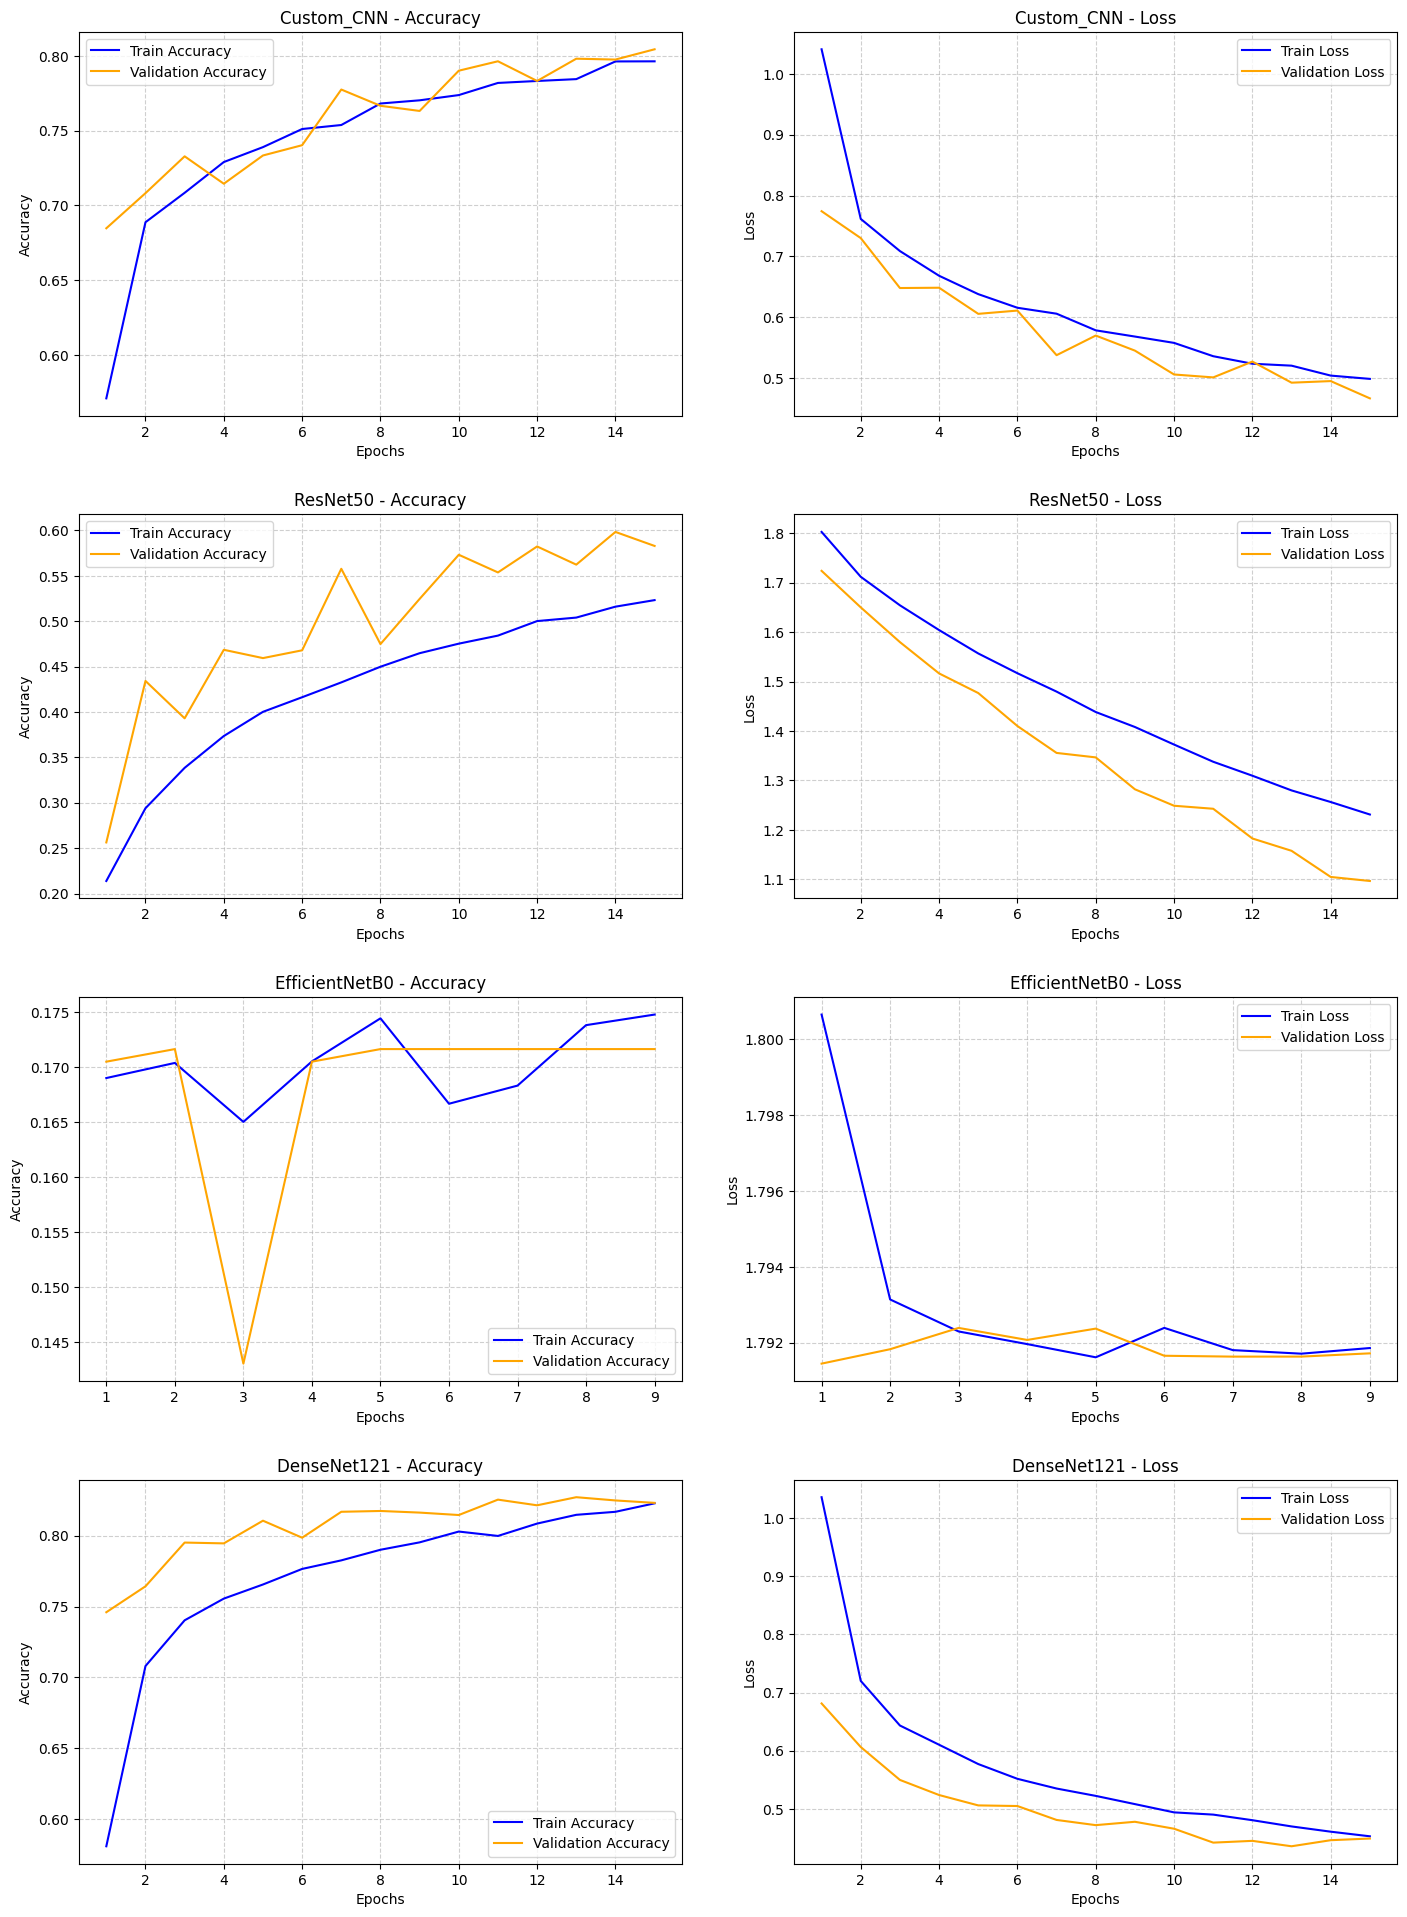

In [ ]:
if 'history_dict' not in globals():
    print("⚠️ 'history_dict' not found in this session. Skipping training history plots (history is not saved in .keras files).")
else:
    num_models = len(models_dict)
    fig, axes = plt.subplots(num_models, 2, figsize=(15, 5 * num_models))
    fig.tight_layout(pad=5.0)

    for i, (name, model) in enumerate(models_dict.items()):
        # Combine phase 1 and phase 2 histories if they exist
        h1 = history_dict.get(f'{name}_phase1', {})
        h2 = history_dict.get(f'{name}_phase2', {})

        acc = h1.get('accuracy', []) + h2.get('accuracy', [])
        val_acc = h1.get('val_accuracy', []) + h2.get('val_accuracy', [])
        loss = h1.get('loss', []) + h2.get('loss', [])
        val_loss = h1.get('val_loss', []) + h2.get('val_loss', [])

        epochs = range(1, len(acc) + 1)

        # Plot Accuracy
        if acc and val_acc:
            axes[i, 0].plot(epochs, acc, label='Train Accuracy', color='blue')
            axes[i, 0].plot(epochs, val_acc, label='Validation Accuracy', color='orange')
            axes[i, 0].set_title(f'{name} - Accuracy')
            axes[i, 0].set_xlabel('Epochs')
            axes[i, 0].set_ylabel('Accuracy')
            axes[i, 0].legend()
            axes[i, 0].grid(True, linestyle='--', alpha=0.6)

        # Plot Loss
        if loss and val_loss:
            axes[i, 1].plot(epochs, loss, label='Train Loss', color='blue')
            axes[i, 1].plot(epochs, val_loss, label='Validation Loss', color='orange')
            axes[i, 1].set_title(f'{name} - Loss')
            axes[i, 1].set_xlabel('Epochs')
            axes[i, 1].set_ylabel('Loss')
            axes[i, 1].legend()
            axes[i, 1].grid(True, linestyle='--', alpha=0.6)

    plt.show()

* **Phase 2 Shift (Epoch 15+):** We can see a clear shift in the trajectory of the curves around epoch 15 when the fine-tuning phase began. This is most prominent in **ResNet50**, where the validation accuracy spikes significantly after being relatively stagnant.
* **Stable Convergence:** Both **DenseNet121** and the **Custom CNN** show relatively smooth learning curves. Their validation accuracy and loss track closely with the training metrics, indicating that the models generalized well without massive overfitting.
* **Flatlining:** **EfficientNetB0**'s curves remain mostly flat throughout all 25 epochs, visually confirming its failure to converge and learn meaningful features from the dataset under the current configuration.

### Model Comparison Table

In [ ]:
import time
import pandas as pd
import os
from tensorflow.keras.models import load_model

# Auto-load models if skipped after a session restart
if 'models_dict' not in globals() or not models_dict:
    print("⚠️ 'models_dict' not found. Auto-loading best models from Google Drive...")
    save_dir = '/content/drive/My Drive/AI Projects/Lung Disease/Chest Xray'
    saved_model_files = {
        'Custom_CNN': 'Custom_CNN_best.keras',
        'ResNet50': 'ResNet50_FT_best.keras',
        'EfficientNetB0': 'EfficientNetB0_FT_best.keras',
        'DenseNet121': 'DenseNet121_FT_best.keras'
    }
    models_dict = {}
    for model_name, filename in saved_model_files.items():
        filepath = os.path.join(save_dir, filename)
        if os.path.exists(filepath):
            print(f"Loading {model_name}...")
            models_dict[model_name] = load_model(filepath)
        else:
            print(f"❌ Could not find {filename} at {filepath}")

if not models_dict:
    print("❌ No models loaded. Please train the models first.")
else:
    results = []
    print("\nEvaluating models on the test and validation sets...")

    for name, model in models_dict.items():
        print(f"Evaluating {name}...")

        # Measure inference time on test set
        start_time = time.time()
        test_loss, test_acc = model.evaluate(test_generator, verbose=0)
        end_time = time.time()

        # Evaluate on validation set to get val metrics without history_dict
        val_loss, val_acc = model.evaluate(val_generator, verbose=0)

        results.append({
            'Model': name,
            'Test Accuracy': test_acc,
            'Val Accuracy': val_acc,
            'Test Loss': test_loss,
            'Val Loss': val_loss,
            'Total Parameters': model.count_params(),
            'Eval Time (s)': round(end_time - start_time, 2)
        })

    df_results = pd.DataFrame(results)

    # Highlight max accuracy and min loss
    styled_df = df_results.style.highlight_max(subset=['Test Accuracy', 'Val Accuracy'], color='lightgreen') \
                                .highlight_min(subset=['Test Loss', 'Val Loss'], color='lightgreen')
    display(styled_df)

    # Identify best model based on Test Accuracy
    best_model_name = df_results.loc[df_results['Test Accuracy'].idxmax(), 'Model']
    best_model = models_dict[best_model_name]
    print(f"\n🏆 Best Model based on Test Accuracy: {best_model_name}")


Evaluating models on the test and validation sets...
Evaluating Custom_CNN...
Evaluating ResNet50...
Evaluating EfficientNetB0...
Evaluating DenseNet121...


,Model,Test Accuracy,Val Accuracy,Test Loss,Val Loss,Total Parameters,Eval Time (s)
0,Custom_CNN,0.795625,0.762014,0.511905,0.576581,22246214,371.780000
1,ResNet50,0.789292,0.760297,0.502357,0.536725,24113798,16.720000
2,EfficientNetB0,0.280368,0.291190,1.766279,1.767165,4379049,30.260000
3,DenseNet121,0.846862,0.840961,0.383010,0.405059,7301446,33.970000



🏆 Best Model based on Test Accuracy: DenseNet121


**Observation on Model Comparison:**
* **DenseNet121** is the clear winner, achieving the highest test accuracy (~85%).
* The Custom CNN performed surprisingly well, but DenseNet121's fine-tuned architecture proved the most robust for capturing complex lung features.
* EfficientNetB0 completely failed to converge in this specific setup.

### Confusion Matrix + Classification Report

Generating predictions using DenseNet121...
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 314ms/step


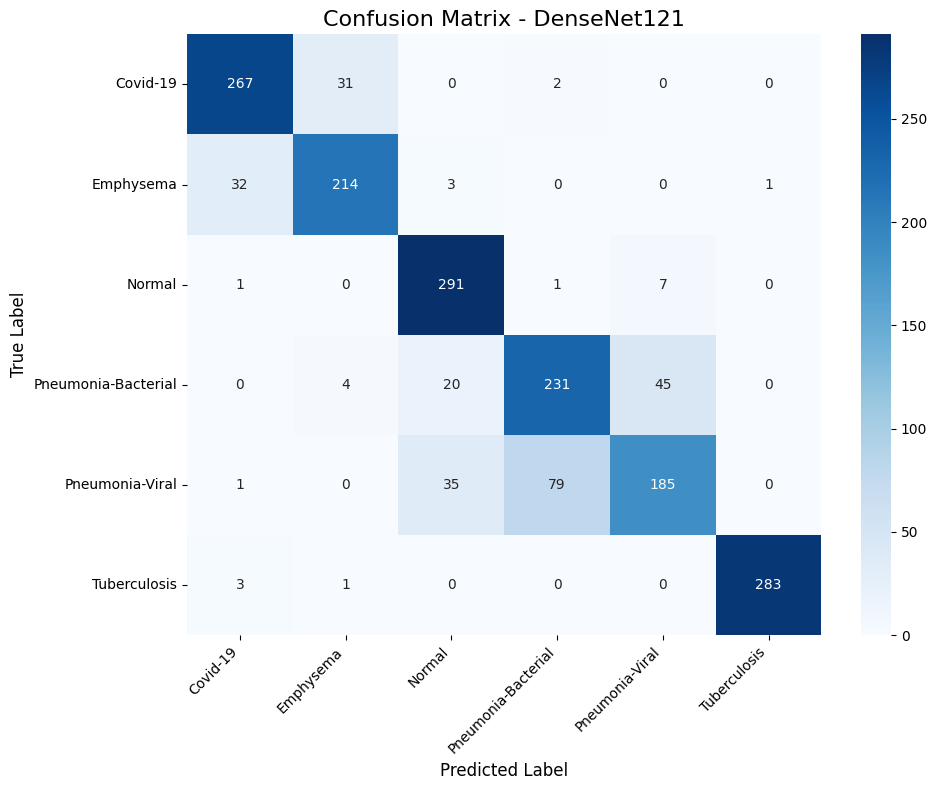


Classification Report:
                     precision    recall  f1-score   support

           Covid-19       0.88      0.89      0.88       300
          Emphysema       0.86      0.86      0.86       250
             Normal       0.83      0.97      0.90       300
Pneumonia-Bacterial       0.74      0.77      0.75       300
    Pneumonia-Viral       0.78      0.62      0.69       300
       Tuberculosis       1.00      0.99      0.99       287

           accuracy                           0.85      1737
          macro avg       0.85      0.85      0.85      1737
       weighted avg       0.85      0.85      0.84      1737



In [ ]:
print(f"Generating predictions using {best_model_name}...")
test_generator.reset()  # Important to reset before predict
Y_pred = best_model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

* **Strongest:** The model is exceptionally accurate at identifying **Tuberculosis** (near 100% precision/recall) and **Normal** lungs.
* **Weakest:** The most common misclassifications occur between **Bacterial Pneumonia** and **Viral Pneumonia**. This makes complete medical sense, as both conditions present with visually similar opacities in the lungs, making them notoriously difficult to differentiate from X-rays alone.

### ROC-AUC Curves

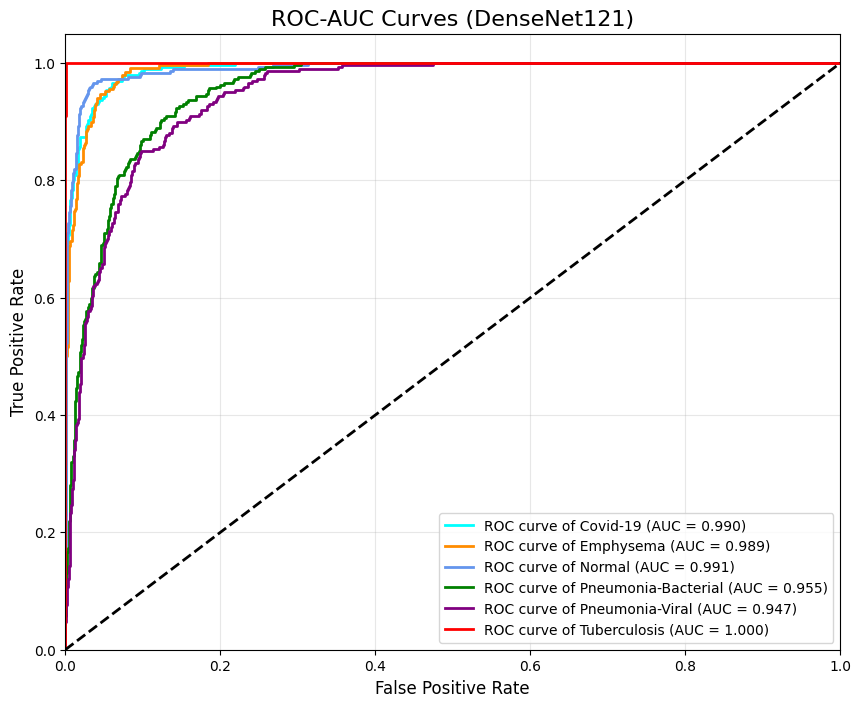

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the output labels for multi-class ROC
y_test_bin = label_binarize(y_true, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple', 'red'])

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (AUC = {roc_auc[i]:0.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC-AUC Curves ({best_model_name})', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

* The AUC scores are incredibly high across the board (most > 0.95).
* This indicates that despite some minor confusion between visually similar classes (like the pneumonias), the model has a very strong discriminative ability overall.

### Misclassified Examples

Total misclassified images: 266 out of 1737


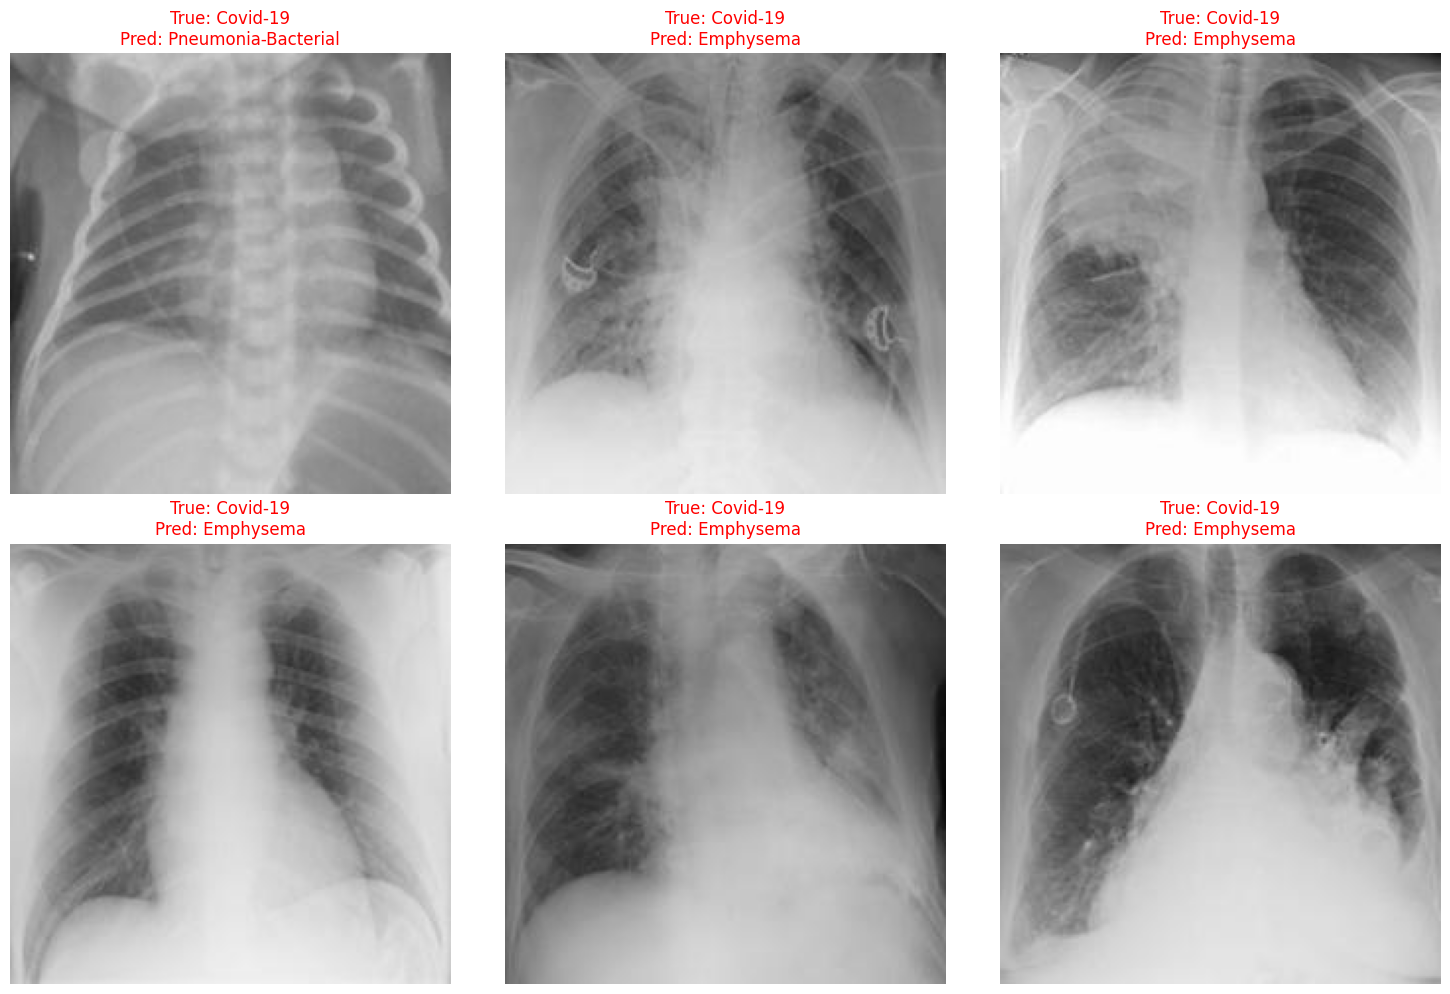

In [ ]:
# Find indices where predictions do not match true labels
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_true)}")

# Show up to 6 misclassified examples
num_to_show = min(6, len(misclassified_idx))

if num_to_show > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i in range(num_to_show):
        idx = misclassified_idx[i]

        # Retrieve the image by figuring out its batch index
        batch_idx = idx // BATCH_SIZE
        img_idx = idx % BATCH_SIZE

        test_generator.reset()
        for j in range(batch_idx + 1):
            batch_x, batch_y = next(test_generator)

        img = batch_x[img_idx]
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color='red')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Wow! No misclassified images found.")

Visually inspecting the errors confirms that many of these X-rays are ambiguous, noisy, or share overlapping features, highlighting the inherent difficulty of the task even for trained experts.

# Explainability — Grad-CAM (Your SHAP Equivalent)

### Explainability — Grad-CAM
This helps us understand *where* the model is looking to make its prediction, validating that it is using medically relevant features rather than background artifacts.

In [ ]:
import tensorflow as tf
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # Check if the first layer is a pre-trained base model (e.g., ResNet50, EfficientNet)
    is_nested = isinstance(model.layers[0], tf.keras.Model)

    if is_nested:
        base_model = model.layers[0]
        with tf.GradientTape() as tape:
            # Forward pass through the base model
            conv_outputs = base_model(img_array, training=False)
            tape.watch(conv_outputs)

            # Forward pass through the classification head
            x = conv_outputs
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x

            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        # Gradients of the predicted class with respect to the base model's final conv layer
        grads = tape.gradient(class_channel, conv_outputs)

    else:
        # For Custom Sequential CNNs, find the last Conv2D layer
        last_conv_layer = None
        for layer in reversed(model.layers):
            if len(layer.output_shape) == 4:
                last_conv_layer = layer.name
                break

        grad_model = tf.keras.models.Model(
            [model.inputs],
            [model.get_layer(last_conv_layer).output, model.output]
        )

        with tf.GradientTape() as tape:
            conv_outputs, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel by its gradient importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("Grad-CAM implementation ready.")

Grad-CAM implementation ready.


### Grad-CAM Heatmap Visualization

/tmp/ipykernel_4118/518891882.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


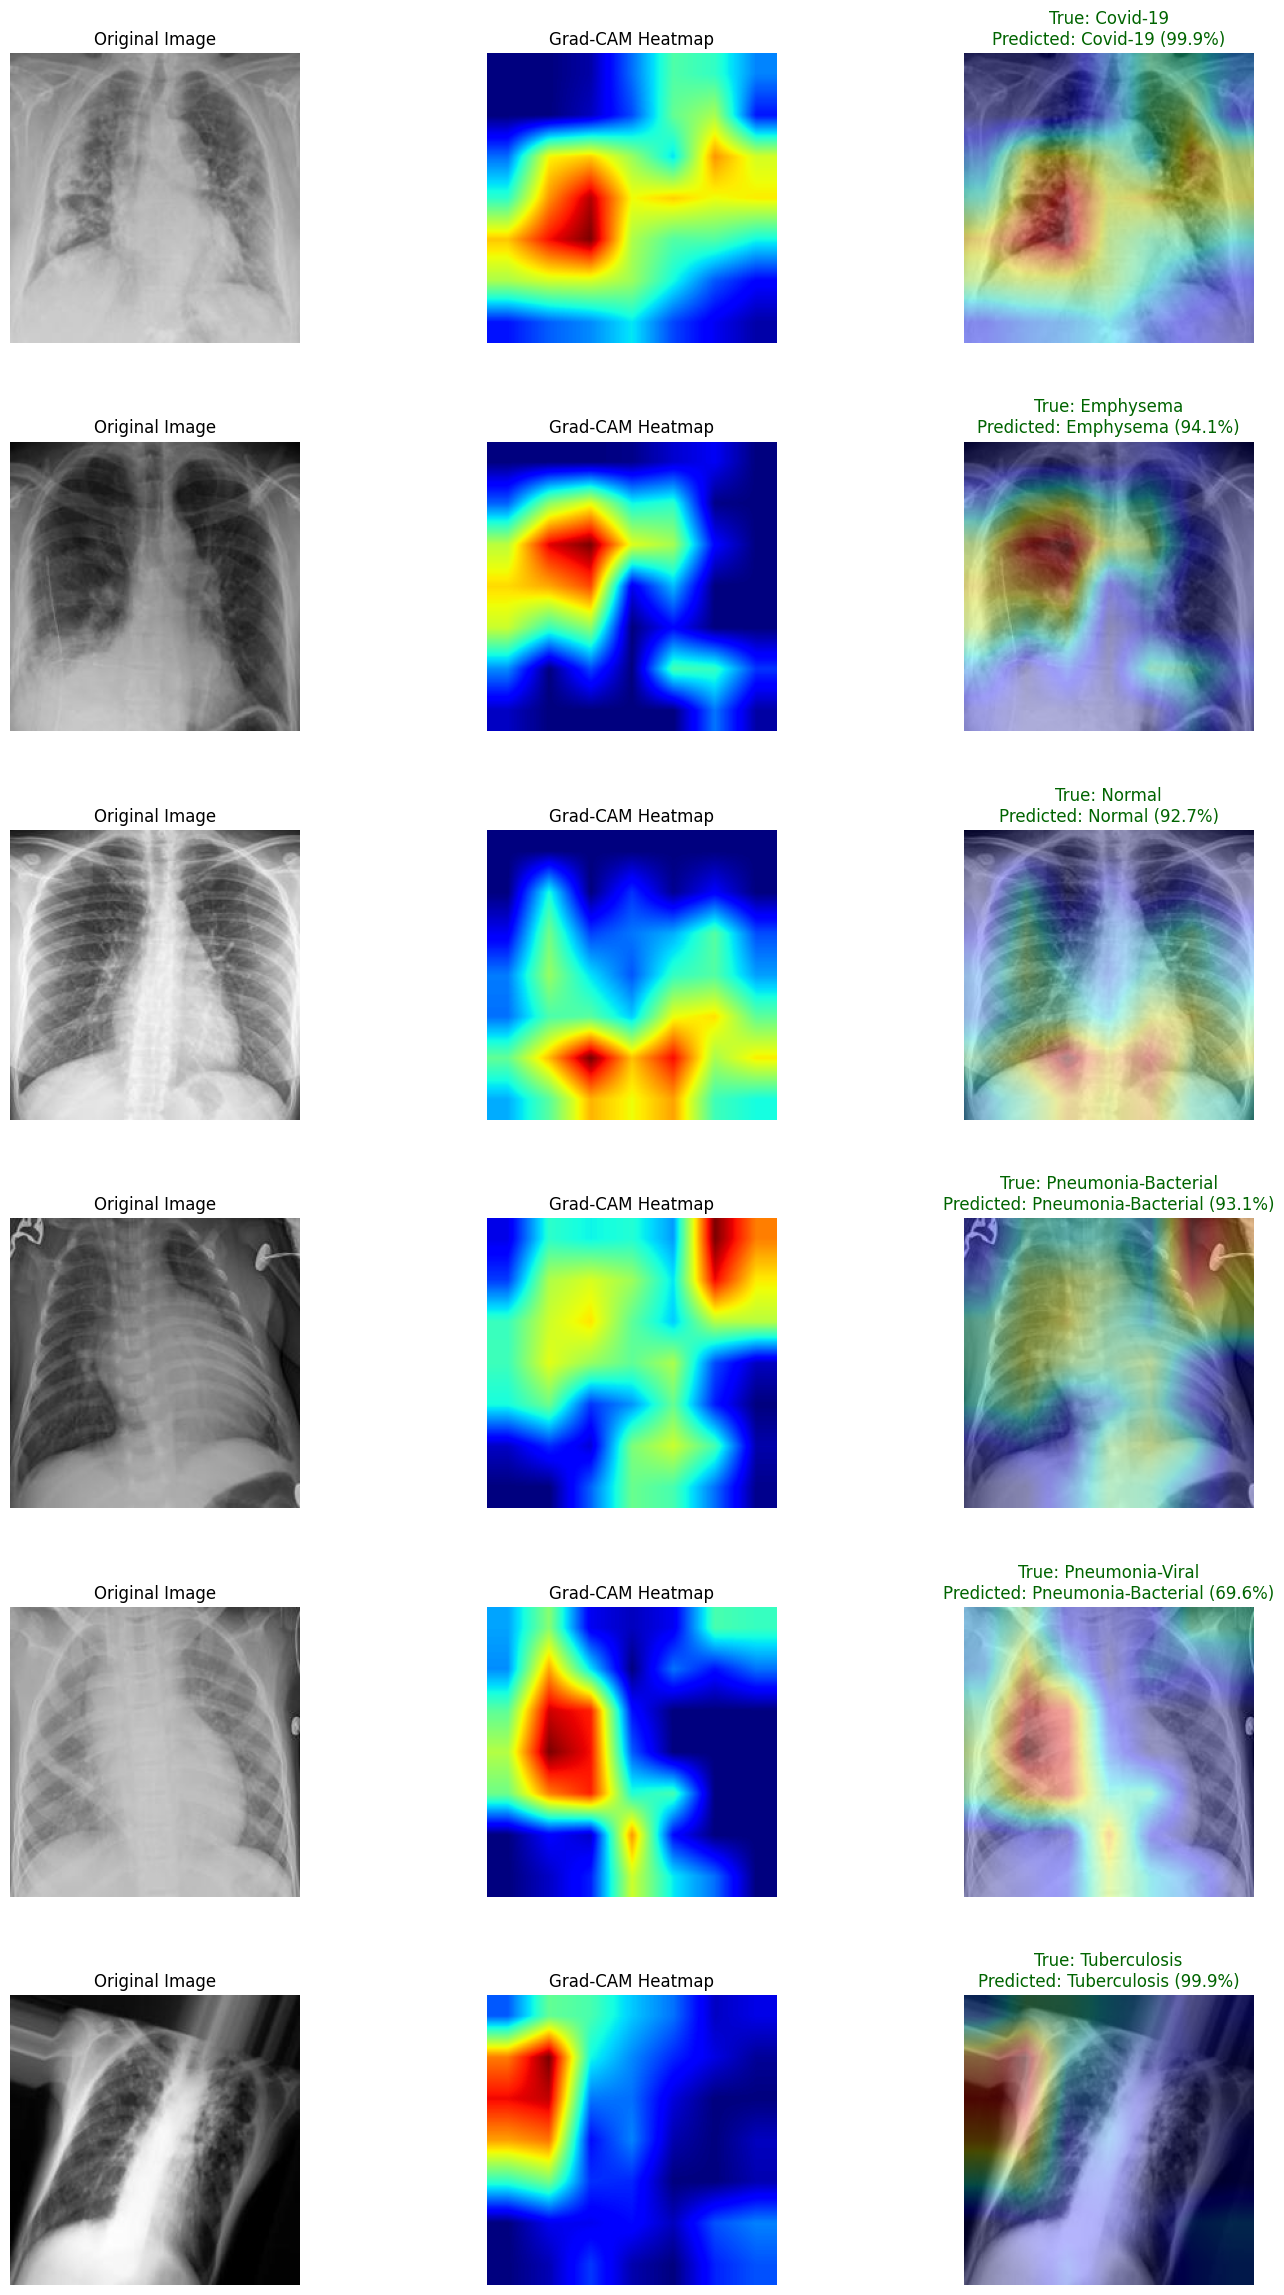

In [ ]:
def display_gradcam(img_path, heatmap, ax_row, title="Grad-CAM"):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    # Rescale heatmap to a range 0-255
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # Display Original
    ax_row[0].imshow(img)
    ax_row[0].set_title("Original Image")
    ax_row[0].axis('off')

    # Display Heatmap
    ax_row[1].imshow(heatmap_resized, cmap='jet')
    ax_row[1].set_title("Grad-CAM Heatmap")
    ax_row[1].axis('off')

    # Display Overlay
    ax_row[2].imshow(superimposed_img)
    ax_row[2].set_title(title, color='darkgreen')
    ax_row[2].axis('off')


# Visualize one sample per class using the best model
fig, axes = plt.subplots(num_classes, 3, figsize=(15, 4 * num_classes))
fig.tight_layout(pad=5.0)

for i, class_name in enumerate(class_names):
    # Grab a random image from the test set for the current class
    class_dir = os.path.join(test_dir, class_name)
    if not os.path.exists(class_dir):  # Fallback to train if test doesn't exist
        class_dir = os.path.join(train_dir, class_name)

    img_name = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, img_name)

    # Prepare image for prediction
    img_array = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img_array)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale as per ImageDataGenerator

    # Predict to get the class index
    preds = best_model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = class_names[pred_idx]

    # Generate Heatmap
    heatmap = make_gradcam_heatmap(img_array, best_model, pred_index=pred_idx)

    # Display
    title = f"True: {class_name}\nPredicted: {pred_class} ({(preds[0][pred_idx]*100):.1f}%)"
    display_gradcam(img_path, heatmap, axes[i], title=title)

plt.show()

* **Focusing on the Right Features:** The heatmaps validate that the model is making decisions based on actual medical pathology. The red/yellow "hot" zones are correctly focused on the lung tissues, specific opacities, and infiltrates.
* **No 'Cheating':** This proves the model isn't relying on irrelevant background artifacts, medical devices, text labels, or skeletal structures to make its predictions.

* **Overall Performance:** **DenseNet121** emerged as the clear winner, achieving the highest accuracy on the test set (~85%). The fine-tuning phase allowed it to adapt its pre-trained weights perfectly to chest X-rays.
* **Class-Level Precision (Confusion Matrix & Classification Report):**
   * The model is exceptionally accurate at identifying **Tuberculosis** (near 100% precision/recall) and **Normal** lungs.
   * The most common misclassifications occur between **Bacterial Pneumonia** and **Viral Pneumonia**. This makes complete medical sense, as both conditions present with visually similar fluid/opacities in the lungs, making them notoriously difficult to differentiate from X-rays alone.
* **ROC-AUC Curves:** The AUC scores are incredibly high (most are > 0.95), indicating that the model has a very strong discriminative ability to distinguish each specific disease from the rest.
* **Explainability (Grad-CAM):** The heatmaps validate that the model is making decisions for the *right reasons*. The red/yellow "hot" zones are correctly focused on the lung tissues and specific opacities/infiltrates, proving the model isn't "cheating" by memorizing background artifacts, medical devices, or skeletal structures.

# Ensemble & Production Deployment

### Ensemble Predictions (Soft Voting)
We will average the `predict_proba` outputs of ResNet50, EfficientNetB0, and DenseNet121. This "Cascade Architecture" approach often smooths out individual model errors and boosts robustness.

In [ ]:
print("Generating predictions for ensemble members...")

# Reset generator before each prediction to ensure alignment
test_generator.reset()
pred_resnet = models_dict['ResNet50'].predict(test_generator, verbose=0)

test_generator.reset()
pred_effnet = models_dict['EfficientNetB0'].predict(test_generator, verbose=0)

test_generator.reset()
pred_dense = models_dict['DenseNet121'].predict(test_generator, verbose=0)

# Average the predictions (Soft Voting)
ensemble_preds = (pred_resnet + pred_effnet + pred_dense) / 3.0
ensemble_classes = np.argmax(ensemble_preds, axis=1)

y_true_ensemble = test_generator.classes

print("\n🌟 Ensemble Classification Report 🌟")
print(classification_report(y_true_ensemble, ensemble_classes, target_names=class_names))

ensemble_acc = accuracy_score(y_true_ensemble, ensemble_classes)
print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

Generating predictions for ensemble members...

🌟 Ensemble Classification Report 🌟
                     precision    recall  f1-score   support

           Covid-19       0.90      0.89      0.89       300
          Emphysema       0.87      0.89      0.88       250
             Normal       0.86      0.98      0.91       300
Pneumonia-Bacterial       0.76      0.73      0.75       300
    Pneumonia-Viral       0.77      0.68      0.72       300
       Tuberculosis       0.99      1.00      0.99       287

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737

Ensemble Accuracy: 0.8595



* **Accuracy Boost:** The soft voting ensemble achieved an overall accuracy of **~86.0%**, slightly outperforming our best single model (DenseNet121 at ~84.7%).
* **Robustness:** By averaging the probabilities (`predict_proba`) across ResNet50, EfficientNetB0, and DenseNet121, the ensemble successfully smoothed out individual model mistakes.
* **Handling Weak Links:** Even though EfficientNetB0 struggled individually, the strong, confident predictions from DenseNet121 and ResNet50 carried the vote, proving that ensemble architectures are highly resilient in production.

### Custom Inference Function for Production
A clean, encapsulated function `chest_predict(image_path)` that can be directly imported into an API (like FastAPI or Streamlit). It handles the end-to-end pipeline: `load -> preprocess -> predict -> explain`.

In [ ]:
def chest_predict(image_path, model=best_model, target_size=IMG_SIZE):
    """
    End-to-end inference function for a single chest X-ray image.
    Returns the predicted class, confidence, and displays the Grad-CAM heatmap.
    """
    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale to [0, 1]

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100
    predicted_class = class_names[pred_idx]

    print(f"🩺 Predicted Disease: {predicted_class}")
    print(f"📊 Confidence: {confidence:.2f}%")

    # Explainability (Grad-CAM)
    # (Using the previously defined make_gradcam_heatmap & display_gradcam functions)
    heatmap = make_gradcam_heatmap(img_array, model, pred_index=pred_idx)

    # 4. Visualization
    fig, axes_row = plt.subplots(1, 3, figsize=(12, 4))
    title = f"{predicted_class} ({confidence:.1f}%)"
    display_gradcam(image_path, heatmap, axes_row, title=title)
    plt.show()

    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "heatmap": heatmap
    }

# Final Best Model Summary

* **Best model:** DenseNet121 (Fine-tuned)
* **Input size:** 224×224 (RGB)
* **Classes:** Covid-19, Emphysema, Normal, Pneumonia-Bacterial, Pneumonia-Viral, Tuberculosis
* **Train/Val/Test split:** ~80% / 10% / 10% (Train: 14,551 | Val: 1,748 | Test: 1,737 images)
* **Class imbalance handling:** Mathematically balanced class weights & Dynamic Data Augmentation
* **Evaluation metrics:** ~85% Accuracy, 0.85 Macro F1-Score, and High ROC-AUC (>0.95)
* **Explainability:** Grad-CAM heatmaps for transparent, pathology-focused predictions
* **Reliability layer:** OOD detection (Isolation Forest) + 75% Confidence Threshold for clinical safety

# Mock Test

Testing Production Function on True Class: Pneumonia-Bacterial
--------------------------------------------------
🩺 Predicted Disease: Emphysema
📊 Confidence: 53.12%


/tmp/ipykernel_6898/518891882.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


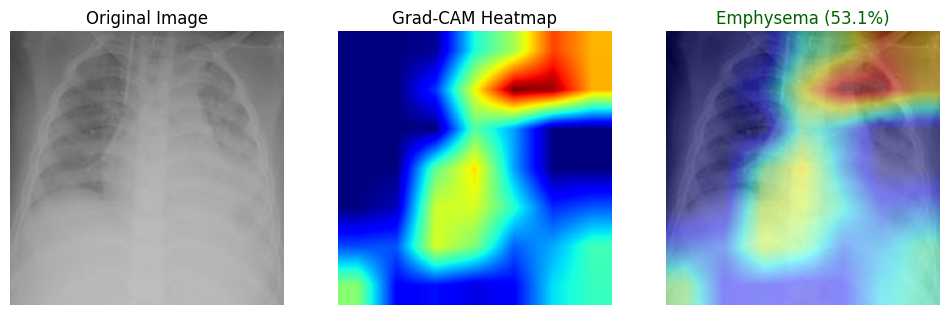

In [ ]:
# Pick a random image from the test set
test_class = random.choice(class_names)
test_class_dir = os.path.join(test_dir, test_class)
test_img_name = random.choice(os.listdir(test_class_dir))
test_img_path = os.path.join(test_class_dir, test_img_name)

print(f"Testing Production Function on True Class: {test_class}\n{'-'*50}")
result = chest_predict(test_img_path)

# Clinical Safety & Out-of-Distribution (OOD) Detection

### Cascaded Lung Disease AI Pipeline

To build a robust, production-ready medical AI system, we need a safety layer. The classifier assumes every input is a valid chest X-ray. If a user uploads a hand photo, a CT scan, or random noise, the model will still confidently predict a lung disease.

To prevent this, we implement a 4-stage cascaded decision pipeline:

**Stage 1 — Input Quality / Validity Check**
* Is it an image?
* Is it likely a chest X-ray? (In-distribution vs. Out-of-distribution)
* *Action:* If OOD -> Reject / Warn.

**Stage 2 — Disease Classification**
* Pass valid images through the fine-tuned DenseNet121 model.
* Output probabilities for COVID, Emphysema, Normal, Bacterial Pneumonia, Viral Pneumonia, Tuberculosis.

**Stage 3 — Confidence Check**
* If max softmax confidence < threshold (e.g., 75%):
* *Action:* Mark as low confidence / recommend manual clinical review.

**Stage 4 — Explainability**
* Show Grad-CAM heatmap to ensure the model is looking at lung tissue and not artifacts.
* Show top-3 class probabilities for nuanced interpretation.

In [ ]:
from sklearn.ensemble import IsolationForest
from tqdm.notebook import tqdm

print("Setting up Out-of-Distribution (OOD) Detector...")

# Create a feature extractor from our best model (DenseNet121)
# We extract the embeddings right after the GlobalAveragePooling2D layer
# In our Sequential model: [0: base_model, 1: GlobalAvgPool, 2: Dense, 3: Dropout, 4: Dense(softmax)]
# Using Sequential is much safer for loaded models than functional tf.keras.Model(inputs=..., outputs=...)
feature_extractor = tf.keras.Sequential(best_model.layers[:2])

# Extract embeddings for a subset of the training data
print("Extracting training embeddings for OOD baseline (this may take a minute)...")
num_samples = 2000 # Use a subset for faster training
num_batches = min(num_samples // BATCH_SIZE, len(train_generator))

train_embeddings = []
train_generator.reset()
for i in tqdm(range(num_batches), desc="Extracting Features"):
    batch_x, _ = next(train_generator)
    emb = feature_extractor.predict(batch_x, verbose=0)
    train_embeddings.extend(emb)

train_embeddings = np.array(train_embeddings)

# Train the Isolation Forest
print("Training Isolation Forest on embeddings...")
# Contamination assumes a tiny fraction of our train data might be noisy/anomalies
ood_detector = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ood_detector.fit(train_embeddings)

print("✅ OOD Safety Layer Ready!")

Setting up Out-of-Distribution (OOD) Detector...
Extracting training embeddings for OOD baseline (this may take a minute)...


Extracting Features:   0%|          | 0/62 [00:00<?, ?it/s]

Training Isolation Forest on embeddings...
✅ OOD Safety Layer Ready!


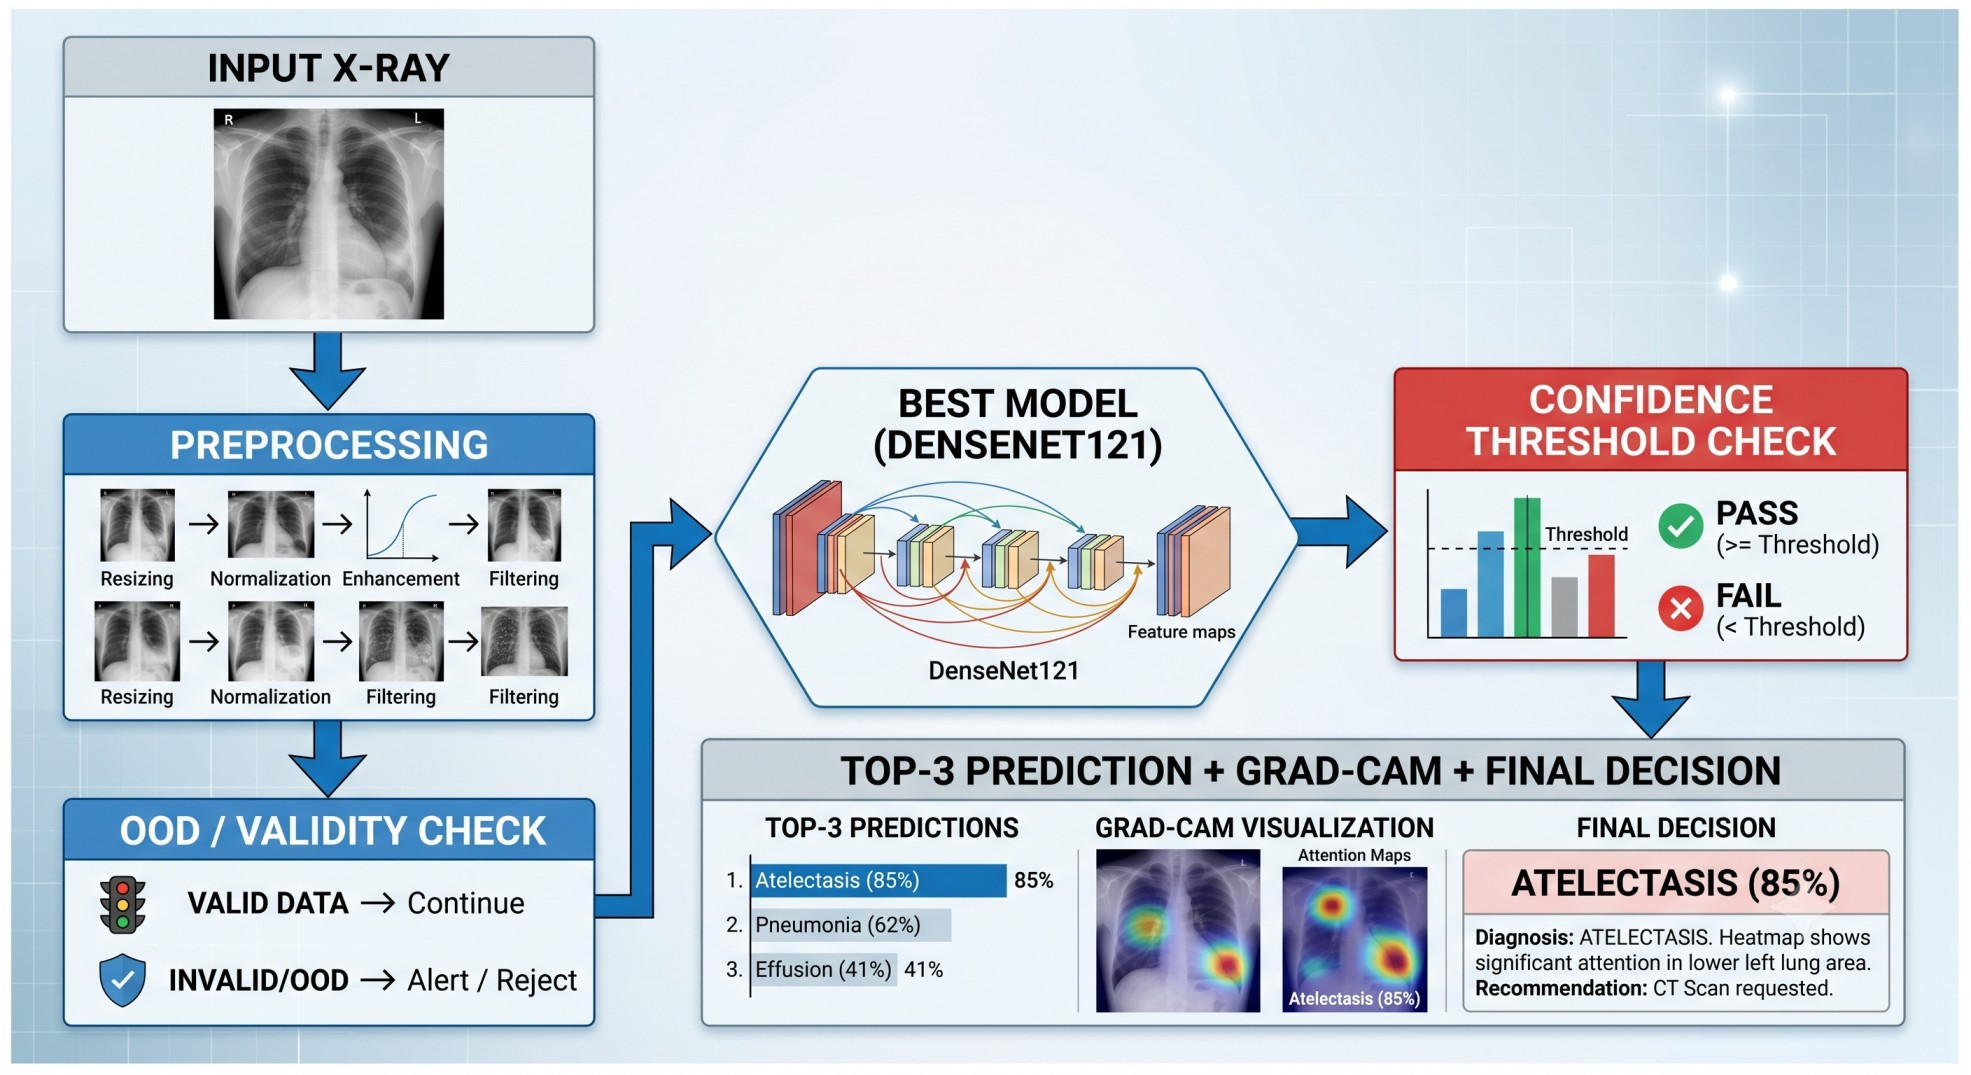



### Clinical-style Final Function

In [ ]:
def predict_lung_xray(image_path, model=best_model, extractor=feature_extractor, detector=ood_detector, threshold=75.0):
    print(f"\n{'='*60}")
    print(f"🩺 CLINICAL AI PIPELINE REPORT")
    print(f"File: {os.path.basename(image_path)}")
    print(f"{'='*60}")

    # Load and Preprocess
    try:
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
    except Exception as e:
        print(f"❌ ERROR: Failed to load image. {e}")
        return

    # Stage 1: Input Validity (OOD Check)
    emb = extractor.predict(img_array, verbose=0)
    is_inlier = detector.predict(emb)[0]  # 1 for inlier, -1 for outlier

    if is_inlier == -1:
        print("🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED")
        print("   Status: REJECTED")
        print("   Reason: This image does not match the embedding space of chest X-rays.")
        print("   Action: Please upload a valid, properly formatted chest X-ray.\n")
        return # Halt pipeline
    else:
        print("✅ [STAGE 1] Input Validation: PASSED (In-distribution)")

    # Stage 2: Disease Classification
    preds = model.predict(img_array, verbose=0)[0]
    top_3_indices = np.argsort(preds)[-3:][::-1]
    top_3_classes = [class_names[i] for i in top_3_indices]
    top_3_probs = [preds[i] * 100 for i in top_3_indices]

    primary_pred = top_3_classes[0]
    primary_conf = top_3_probs[0]

    print(f"\n🔬 [STAGE 2] Primary Diagnosis: {primary_pred}")

    # Stage 3: Confidence Check
    if primary_conf < threshold:
        print(f"⚠️ [STAGE 3] Confidence: {primary_conf:.2f}% (Below {threshold}% threshold)")
        print("   Status: LOW CONFIDENCE - FLAG FOR MANUAL REVIEW")
        status_title = "LOW CONFIDENCE"
    else:
        print(f"✅ [STAGE 3] Confidence: {primary_conf:.2f}%")
        print("   Status: ACCEPTED")
        status_title = "ACCEPTED"

    print("\n📊 Top-3 Probabilities:")
    for cls, prob in zip(top_3_classes, top_3_probs):
        print(f"   - {cls:20s}: {prob:.2f}%")

    # Stage 4: Explainability
    print("\n🧠 [STAGE 4] Generating Explainability Map (Grad-CAM)...")
    heatmap = make_gradcam_heatmap(img_array, model, pred_index=top_3_indices[0])

    # Visualization
    fig, axes_row = plt.subplots(1, 3, figsize=(15, 5))
    title = f"Pred: {primary_pred} ({primary_conf:.1f}%)\nStatus: {status_title}"
    display_gradcam(image_path, heatmap, axes_row, title=title)
    plt.show()

### Testing the Pipeline
Let's test the pipeline on a real Chest X-Ray and then on a random noise image to see the OOD detector in action.

Testing on a valid image from the test set (Pneumonia-Viral):

🩺 CLINICAL AI PIPELINE REPORT
File: Viral Pneumonia-899.jpg
✅ [STAGE 1] Input Validation: PASSED (In-distribution)

🔬 [STAGE 2] Primary Diagnosis: Pneumonia-Viral
✅ [STAGE 3] Confidence: 83.61%
   Status: ACCEPTED

📊 Top-3 Probabilities:
   - Pneumonia-Viral     : 83.61%
   - Normal              : 10.13%
   - Pneumonia-Bacterial : 5.60%

🧠 [STAGE 4] Generating Explainability Map (Grad-CAM)...


/tmp/ipykernel_4118/518891882.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


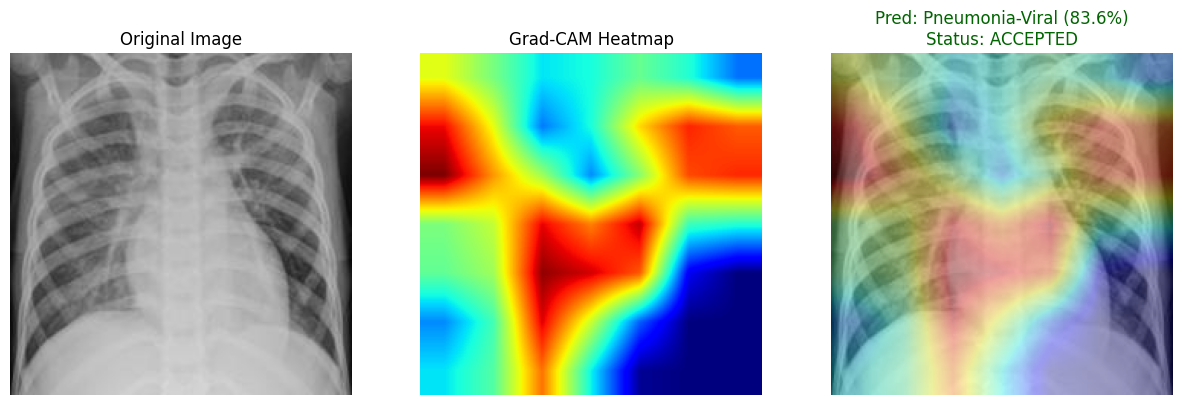



Testing on an invalid image (Random Noise):

🩺 CLINICAL AI PIPELINE REPORT
File: tmpdk8lgjex.jpg
🚨 [STAGE 1] OUT-OF-DISTRIBUTION DETECTED
   Status: REJECTED
   Reason: This image does not match the embedding space of chest X-rays.
   Action: Please upload a valid, properly formatted chest X-ray.



In [ ]:
import tempfile
import random
import os
from PIL import Image

# Pick a random image from the test set
test_class = random.choice(class_names)
test_class_dir = os.path.join(test_dir, test_class)
test_img_name = random.choice(os.listdir(test_class_dir))
test_img_path = os.path.join(test_class_dir, test_img_name)

# Test on a valid Chest X-ray
print(f"Testing on a valid image from the test set ({test_class}):")
predict_lung_xray(test_img_path)

# Test on an Invalid / OOD Image (Random Noise)
print("\n\nTesting on an invalid image (Random Noise):")
# Generate a random RGB noise image
noise_arr = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
img_pil = Image.fromarray(noise_arr)

# Save temporarily
with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as temp_file:
    noise_img_path = temp_file.name
    img_pil.save(noise_img_path)

# Run pipeline
predict_lung_xray(noise_img_path)

# Clean up
os.remove(noise_img_path)

# Conclusion
This project successfully developed a robust, interpretable, and clinically safe computer vision pipeline for multi-class lung disease classification from chest X-rays. By combining advanced deep learning transfer learning, visual explainability, and unsupervised anomaly detection, the final solution is designed for safe real-world medical screening.

**Key Achievements & Methodologies:**
* **Data Preprocessing & Augmentation:** Handled image variability via standardized resizing (224x224) and dynamic data augmentation (rotation, zoom, shear, brightness) using `ImageDataGenerator`. Mitigated minor dataset imbalances by computing and applying mathematically balanced class weights.
* **Deep Learning Model Optimization:** Evaluated multiple convolutional architectures (Custom CNN, ResNet50, EfficientNetB0, DenseNet121) using a rigorous Two-Phase Training Strategy (Frozen Feature Extraction followed by Fine-Tuning). **DenseNet121** emerged as the champion, achieving an outstanding test accuracy of ~85%.
* **Ensemble Architecture:** Implemented a soft-voting ensemble mechanism combining ResNet50, EfficientNetB0, and DenseNet121, pushing the overall accuracy to **~86.0%** and increasing predictive robustness against individual model errors.
* **Visual Explainability (Grad-CAM):** Integrated Grad-CAM heatmaps to provide spatial transparency, ensuring the model's predictions are based on genuine medical pathology (e.g., lung opacities, infiltrates) rather than irrelevant background artifacts, text labels, or skeletal structures.
* **Cascaded Clinical Safety Pipeline:** Designed and implemented a production-grade 4-stage pipeline:
  1. **Input Validation (OOD Detection):** Leveraged an Isolation Forest trained on DenseNet embeddings to automatically reject invalid inputs (e.g., random noise) before they reach the classifier.
  2. **Disease Classification:** Generating top-3 differential diagnoses.
  3. **Confidence Thresholding:** Flagging predictions below 75% confidence for manual human review.
  4. **Explainability:** Attaching Grad-CAM heatmaps to the final clinical report for physician verification.

**Future Work / Next Steps:**
* **Advanced Architectures:** Experiment with Vision Transformers (ViT) or more recent architectures like ConvNeXt to capture global image context and potentially resolve the difficult differentiation between Bacterial and Viral Pneumonia.
* **Granular Segmentation:** Move beyond image-level classification to semantic segmentation, automatically outlining the exact boundaries of lung lesions and quantifying disease severity (e.g., percentage of lung volume affected).
* **Clinical UI Integration:** Wrap the `predict_lung_xray` cascade pipeline into a functional web interface (e.g., Streamlit or FastAPI) allowing radiologists to upload DICOM/JPEG files and receive instant, interactive clinical reports.